# Propiedades de los Estimadores en R

## Econometría I — Insesgadez, eficiencia y consistencia, vistas con simulación

### Profesor Luis E. Peñafiel

> **Antes de empezar:** este notebook es un poco distinto a los de regresión: acá no vamos a leer la salida de un `lm()`, sino a *ver* con simulaciones qué significan conceptos que hasta ahora solo manejaste con fórmulas — insesgadez, eficiencia, consistencia. La idea es la misma que en Regresión Simple: primero la cuenta a mano, después la verificación en R, y en este caso, además, la posibilidad de *repetir el experimento miles de veces* — algo que a mano sería impensable, y que es justamente donde R aporta algo que el papel no puede darte.

## 📘 Glosario rápido

| Término | En criollo |
|----|----|
| **Parámetro** | El valor real, fijo, que existe en la población pero que no observamos (ej. el ingreso medio verdadero de todos los hogares). |
| **Estimador** | La fórmula o regla que usamos para aproximar el parámetro (ej. $\bar X$). Es aleatorio: cambia de muestra a muestra. |
| **Estimación** | El número concreto que obtenemos al aplicar el estimador a una muestra particular. |
| **Insesgadez** | Que el estimador, en promedio a través de infinitas muestras, "acierta" el valor del parámetro ($E[\hat\theta]=\theta$). No dice nada sobre una muestra en particular. |
| **Eficiencia** | Entre dos estimadores insesgados, el más eficiente es el de menor varianza — el que tiende a estar más "apretado" alrededor del valor verdadero. |
| **Consistencia** | Que a medida que $n\to\infty$, el estimador se acerca cada vez más al parámetro verdadero (converge). |
| **ECM (Error Cuadrático Medio)** | $ECM(\hat\theta) = Var(\hat\theta) + [Sesgo(\hat\theta)]^2$ — combina precisión (varianza) y exactitud (sesgo) en un solo número. |

------------------------------------------------------------------------

## 🧩 Bloque 0 — Lo que ya resolviste a mano

Retomemos el Ejercicio 1.4: una muestra de 6 ingresos mensuales (en miles de \$).

In [1]:
ingresos <- c(850, 1200, 650, 980, 1100, 720)
ingresos

[1]  850 1200  650  980 1100  720

Ya calculaste a mano la media muestral $\bar X$ y la varianza muestral $S^2$ con la fórmula:

$$\bar X = \frac{1}{n}\sum_{i=1}^n X_i \qquad S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar X)^2$$

In [2]:
n <- length(ingresos)
media_manual <- sum(ingresos) / n
var_manual <- sum((ingresos - media_manual)^2) / (n - 1)

cat("Media (manual):", round(media_manual, 2), "\n")
cat("Varianza (manual):", round(var_manual, 2), "\n")

Media (manual): 916.67 
Varianza (manual): 46426.67 


Ahora comparemos con las funciones nativas de R:

In [3]:
mean(ingresos)
var(ingresos)

[1] 916.6667

[1] 46426.67

### 🔎 Qué mirar acá

`mean()` y `var()` te dan exactamente los mismos números que calculaste a mano — $\bar X \approx 916.67$ y $S^2 \approx 46\,426.67$. Notá que `var()` en R **ya divide por** $n-1$, no por $n$: es la misma convención que usaste en el Ejercicio 1.4c, justamente para que el estimador sea insesgado. Si alguna vez ves un resultado que no coincide, el primer sospechoso es una diferencia entre dividir por $n$ o por $n-1$.

------------------------------------------------------------------------

## 📥 Bloque 1 — Distribución muestral: viendo el Teorema Central del Límite

Acá es donde R hace algo que a mano sería impensable: repetir un experimento de muestreo miles de veces. Retomamos el Ejercicio 2.3 de tu práctica.

In [4]:
set.seed(2024)
medias <- replicate(1000, mean(rnorm(30, mean = 50, sd = 10)))

media_simulada <- mean(medias)
sd_simulada <- sd(medias)
sd_teorico <- 10 / sqrt(30)

cat("Media de las 1000 medias muestrales:", round(media_simulada, 3), "\n")
cat("Desvío estándar empírico:", round(sd_simulada, 3), "\n")
cat("Desvío estándar teórico (σ/√n):", round(sd_teorico, 3), "\n")

Media de las 1000 medias muestrales: 49.976 
Desvío estándar empírico: 1.798 
Desvío estándar teórico (σ/√n): 1.826 


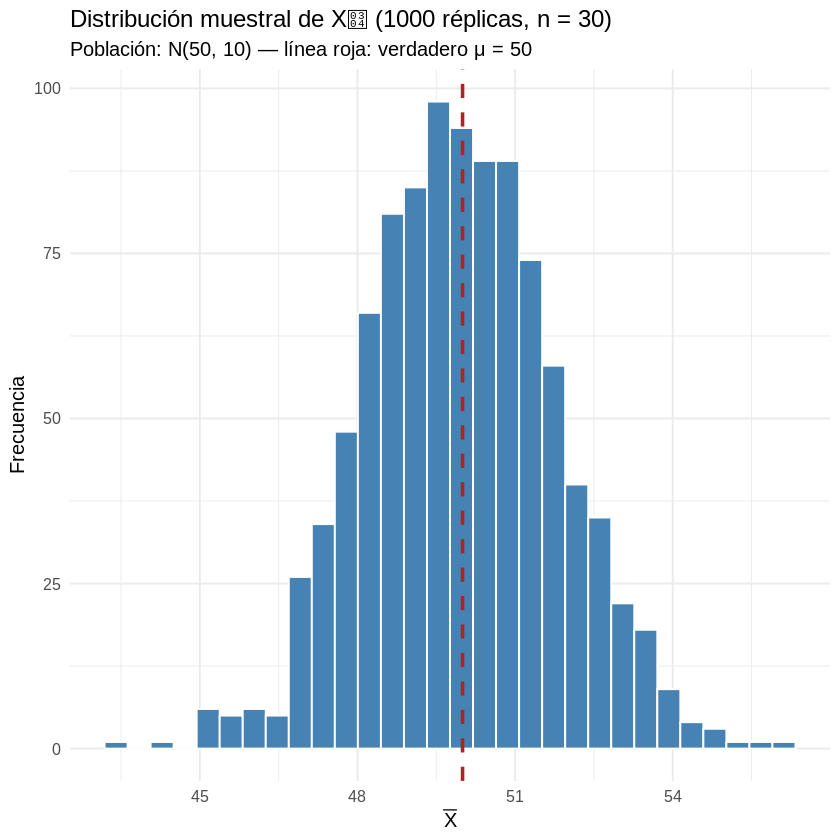

In [5]:
library(ggplot2)

ggplot(data.frame(medias), aes(x = medias)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  geom_vline(xintercept = 50, color = "firebrick", linewidth = 1, linetype = "dashed") +
  labs(title = "Distribución muestral de X̄ (1000 réplicas, n = 30)",
       subtitle = "Población: N(50, 10) — línea roja: verdadero μ = 50",
       x = expression(bar(X)), y = "Frecuencia") +
  theme_minimal(base_size = 12)

### 🔎 Qué mirar acá

El histograma se centra casi exactamente en 50 (el verdadero $\mu$) — eso es **insesgadez** en acción: no en una muestra puntual, sino en el promedio de muchas. Y el desvío estándar empírico (≈1.83) prácticamente coincide con el valor teórico $\sigma/\sqrt{n} = 10/\sqrt{30} \approx 1.83$ — la fórmula que usaste en el Ejercicio 2.1 no es un truco algebraico, es literalmente lo que se observa al repetir el muestreo.

------------------------------------------------------------------------

## 🟢 Bloque 2 — Eficiencia: dos estimadores insesgados, distinta varianza

Retomamos el Ejercicio 3.3 / 4.2: dos estimadores insesgados de $\mu$, construidos con la misma muestra de tamaño $n=50$.

-   $\hat\mu_A = \dfrac{X_1+X_2}{2}$ (promedio de solo las dos primeras observaciones)
-   $\hat\mu_B = \bar X$ (media muestral completa)

In [6]:
set.seed(7)
n <- 50
sigma <- 10
mu_verdadero <- 50

replicas <- replicate(2000, {
  muestra <- rnorm(n, mean = mu_verdadero, sd = sigma)
  c(muA = mean(muestra[1:2]), muB = mean(muestra))
})

muA_sim <- replicas["muA", ]
muB_sim <- replicas["muB", ]

cat("Media de muA:", round(mean(muA_sim), 2), " | Varianza de muA:", round(var(muA_sim), 2), "\n")
cat("Media de muB:", round(mean(muB_sim), 2), " | Varianza de muB:", round(var(muB_sim), 2), "\n")
cat("Razón Var(muA) / Var(muB):", round(var(muA_sim) / var(muB_sim), 1), "\n")

Media de muA: 50.14  | Varianza de muA: 49.34 
Media de muB: 49.99  | Varianza de muB: 2.01 
Razón Var(muA) / Var(muB): 24.5 


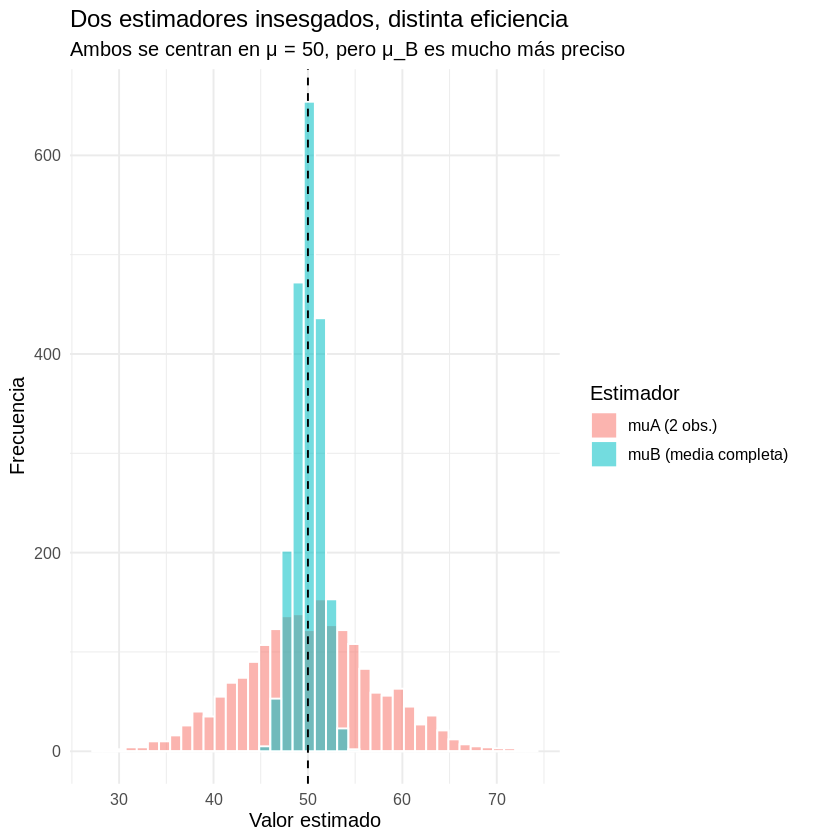

In [7]:
df_comparacion <- data.frame(
  valor = c(muA_sim, muB_sim),
  estimador = rep(c("muA (2 obs.)", "muB (media completa)"), each = 2000)
)

ggplot(df_comparacion, aes(x = valor, fill = estimador)) +
  geom_histogram(position = "identity", alpha = 0.55, bins = 40, color = "white") +
  geom_vline(xintercept = 50, color = "black", linetype = "dashed") +
  labs(title = "Dos estimadores insesgados, distinta eficiencia",
       subtitle = "Ambos se centran en μ = 50, pero μ_B es mucho más preciso",
       x = "Valor estimado", y = "Frecuencia", fill = "Estimador") +
  theme_minimal(base_size = 12)

### 🔎 Qué mirar acá

Las dos distribuciones se centran en el mismo lugar (50) — **ambos estimadores son insesgados**, coherente con lo que demostraste en el Ejercicio 3.3a. Pero $\hat\mu_A$ (naranja/rosado, según el orden de colores por defecto) es muchísimo más ancho: su varianza es aproximadamente 25 veces la de $\hat\mu_B$, el mismo número que te pedía calcular el Ejercicio 4.2 ($\sigma^2/2$ vs $\sigma^2/n$, con $n=50$). Insesgadez no alcanza para elegir un estimador — la eficiencia es el criterio que desempata.

------------------------------------------------------------------------

## 🔵 Bloque 3 — Consistencia: qué pasa cuando crece la muestra

Retomamos el Ejercicio 5.3: la distribución muestral de $\hat\beta_1$ de OLS, para distintos tamaños de muestra.

In [8]:
library(dplyr)

set.seed(100)
sim_data <- bind_rows(lapply(c(20, 50, 200, 1000), function(n) {
  betas <- replicate(1500, {
    x <- runif(n, 0, 10)
    y <- 3 + 2 * x + rnorm(n, 0, 5)
    coef(lm(y ~ x))[2]
  })
  data.frame(n = paste("n =", n), beta = betas)
}))

sim_data$n <- factor(sim_data$n, levels = paste("n =", c(20, 50, 200, 1000)))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
ggplot(sim_data, aes(x = beta)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  geom_vline(xintercept = 2, color = "firebrick", linewidth = 0.8, linetype = "dashed") +
  facet_wrap(~ n, scales = "free_y") +
  coord_cartesian(xlim = c(0.5, 3.5)) +
  labs(x = expression(hat(beta)[1]), y = "Frecuencia",
       title = expression(paste("Distribución muestral de ", hat(beta)[1], " de OLS para distintos n"))) +
  theme_minimal(base_size = 12) +
  theme(strip.text = element_text(face = "bold"))

### 🔎 Qué mirar acá

Las cuatro distribuciones están centradas en $\beta_1 = 2$ (insesgadez, para cualquier $n$) — pero a medida que $n$ crece, la campana se vuelve **cada vez más angosta**, casi una aguja en $n=1000$. Eso es consistencia: no es que el estimador "acierte más" en promedio (ya acertaba desde $n=20$), sino que la probabilidad de estar lejos del verdadero valor se vuelve cada vez menor. Insesgadez es una propiedad de la media de la distribución; consistencia es una propiedad de cómo se comporta esa distribución cuando $n\to\infty$ — son cosas relacionadas, pero no son lo mismo (recordá el Ejercicio 5.1, donde se pide un ejemplo de estimador sesgado pero consistente).

------------------------------------------------------------------------

## ✍️ Para vos — Completá el código

Ahora te toca a vos. Es el Ejercicio 8.2 de tu práctica: comparar la varianza de $\hat\beta_1$ cuando los valores de $x$ tienen mucha dispersión versus poca dispersión, manteniendo todo lo demás igual.

In [ ]:
set.seed(42)
n_sim <- 1500

betas_disp_alta <- replicate(n_sim, {
  x <- runif(100, 0, 100)     # x entre 0 y 100 (mucha dispersión)
  y <- 3 + 0.5 * x + rnorm(100, 0, 10)
  coef(lm(y ~ x))[2]
})

betas_disp_baja <- replicate(n_sim, {
  x <- runif(100, ___, ___)   # completá el rango para que x tenga POCA dispersión
  y <- 3 + 0.5 * x + rnorm(100, 0, 10)
  coef(lm(y ~ x))[2]
})

cat("Varianza con x dispersa:", var(betas_disp_alta), "\n")
cat("Varianza con x concentrada:", var(betas_disp_baja), "\n")

Pistas para completar el rango de `runif(100, ___, ___)`:

-   Tiene que ser un intervalo angosto (poca dispersión), no vacío.
-   El punto medio del intervalo no importa demasiado para el resultado — lo que importa es el **ancho**.

Una vez que lo completes y lo corras, respondé:

1.  ¿Ambos estimadores siguen siendo insesgados (revisá si las medias de `betas_disp_alta` y `betas_disp_baja` siguen cerca de 0.5)?
2.  ¿Cuál de los dos tiene menor varianza? ¿Por qué, según la fórmula $Var(\hat\beta_1) = \dfrac{\sigma^2}{\sum(x_i-\bar x)^2}$?
3.  Si tuvieras que diseñar un experimento y pudieras elegir los valores de $x$, ¿qué rango elegirías para minimizar la varianza de tu estimador?

------------------------------------------------------------------------

## 🏁 Cierre — Así podría aparecer en el examen

En el parcial de lápiz y papel te podés encontrar con una tabla como esta, ya calculada, y te van a pedir que la interpretes:

```         
Estimador     E[θ̂]     Var(θ̂)
θ̂_A           5.0        4.0
θ̂_B           5.8        1.5
```

*(θ verdadero = 5)*

Si podés calcular el sesgo y el ECM de cada uno sin dudar — y explicar por qué la elección "mejor estimador" depende de si el criterio es insesgadez o ECM — este notebook cumplió su objetivo.

------------------------------------------------------------------------

*Notebook — Encuentro Propiedades de los Estimadores. Estructura: Bloque 0 (verificación manual) → Bloque 1 (distribución muestral / TCL) → Bloque 2 (eficiencia) → Bloque 3 (consistencia de OLS) → Ejercicio semi-guiado → Cierre orientado a examen.*